# Creating Dataset

In [15]:
# ============================================================
# DATASET + AUGMENTATION PIPELINE (InferenceSequence PKL)
# ============================================================

import os
import pickle
import numpy as np
import json
from typing import Dict, Tuple, List
from scipy.interpolate import interp1d
from landmarkers.inferences import InferenceSequence
from landmarkers.landmarks import LandmarksSequence

# ------------------------------------------------------------
# Cargar configuración desde config.json
# ------------------------------------------------------------
with open('../config.json', 'r') as f:
    config = json.load(f)

# Datos comunes
common_config = config['common']
ACTIONS = common_config['actions']
SEQUENCE_LENGTH = common_config['sequence_length']
DATA_PATH = common_config['data_path']

# Datos específicos de create_dataset
dataset_config = config['create_dataset']
OUTPUT_PATH = dataset_config['output_path']
augmentation_counts: Dict[str, int] = dataset_config['augmentation_counts']
aug_config = dataset_config['augmentation']
NOISE_STD = aug_config['noise_std']
SCALE_RANGE = tuple(aug_config['scale_range'])
DROPOUT_PROB = aug_config['dropout_prob']
TEMPORAL_PROB = aug_config['temporal_prob']

# ------------------------------------------------------------
# Augmentaciones espaciales
# ------------------------------------------------------------
def add_spatial_noise(seq: np.ndarray, std: float) -> np.ndarray:
	return seq + np.random.normal(0, std, seq.shape)

def scale_sequence(seq: np.ndarray, scale: float) -> np.ndarray:
	return seq * scale

def frame_dropout(seq: np.ndarray, idx: int) -> np.ndarray:
	seq = np.array(seq)
	seq[idx] = 0
	return seq

# ------------------------------------------------------------
# Augmentaciones temporales
# ------------------------------------------------------------
def temporal_interpolation(
	seq: np.ndarray,
	sub_start: int,
	sub_end: int,
	sequence_length: int
) -> np.ndarray:
	sub_seq = seq[sub_start:sub_end]
	x_old = np.linspace(0, 1, num=len(sub_seq))
	x_new = np.linspace(0, 1, num=sequence_length)
	f = interp1d(x_old, sub_seq, axis=0)
	return f(x_new)

def temporal_padding(
	seq: np.ndarray,
	sub_start: int,
	sub_end: int,
	sequence_length: int
) -> np.ndarray:
	sub_seq = seq[sub_start:sub_end]
	pad_len = sequence_length - len(sub_seq)
	pad_front = pad_len // 2
	pad_back = pad_len - pad_front
	return np.vstack([
		np.tile(sub_seq[0], (pad_front, 1, 1)),
		sub_seq,
		np.tile(sub_seq[-1], (pad_back, 1, 1))
	])

# ------------------------------------------------------------
# Pipeline de augmentación principal
# ------------------------------------------------------------
def augment_sequence(
	seq: np.ndarray,
	sequence_length: int,
	noise_std: float = NOISE_STD,
	scale_range: Tuple[float, float] = SCALE_RANGE,
	dropout_prob: float = DROPOUT_PROB,
	temporal_prob: float = TEMPORAL_PROB
) -> np.ndarray:
	seq = np.array(seq)
	orig_len = len(seq)

	# Ruido espacial
	if np.random.rand() < 1.0:
		seq = add_spatial_noise(seq, noise_std)

	# Escalado
	if np.random.rand() < 1.0:
		scale = np.random.uniform(*scale_range)
		seq = scale_sequence(seq, scale)

	# Frame dropout
	if np.random.rand() < dropout_prob:
		idx = np.random.randint(0, orig_len)
		seq = frame_dropout(seq, idx)

	# Transformaciones temporales
	if np.random.rand() < temporal_prob:
		sub_start = np.random.randint(0, orig_len // 2)
		sub_end = sub_start + np.random.randint(orig_len // 2, orig_len)
		sub_end = min(sub_end, orig_len)

		if np.random.rand() < 0.5:
			seq = temporal_interpolation(seq, sub_start, sub_end, sequence_length)
		else:
			seq = temporal_padding(seq, sub_start, sub_end, sequence_length)

	return seq.astype(np.float32)

# ------------------------------------------------------------
# Funcion sigmoide
# ------------------------------------------------------------
def sigmoid(x):
    return np.where(
        x >= 0,
        1 / (1 + np.exp(-x)),
        np.exp(x) / (1 + np.exp(x))
    )

# ------------------------------------------------------------
# Obtener velocidades del centroide normalizadas
# ------------------------------------------------------------
def get_centroid_velocity_norm_sequence(landmark_sequence) -> np.ndarray:
    """
    Devuelve un array (T, 3) con la velocidad del centroide
    normalizada mediante sigmoide.
    """
    time_stamps = np.array(landmark_sequence.time_stamps_ms, dtype=np.float32)
    centroids = np.array(landmark_sequence.centroid(), dtype=np.float32)
    d_centroids = np.diff(centroids, axis=0)          # (T-1, 3)
    d_time = np.diff(time_stamps)[:, None]            # (T-1, 1)
    d_time[d_time == 0] = 1e-6
    velocity = d_centroids / d_time                   # (T-1, 3)
    norms = np.linalg.norm(velocity, axis=1, keepdims=True)
    norms[norms == 0] = 1e-6
    norm_velocity = (sigmoid(norms) / norms) * velocity
    norm_velocity = np.vstack([
        np.zeros((1, 3), dtype=np.float32),
        norm_velocity
    ])

    return norm_velocity.astype(np.float32)
    


def load_sequence_from_pkl(pkl_path: str) -> np.ndarray:
    """
    Devuelve array shape (T, 22, 3)
    21 landmarks originales + 1 vector de velocidad del centroide por frame
    """
    with open(pkl_path, "rb") as f:
        infrence_sequence: InferenceSequence = pickle.load(f)  # InferenceSequence

    landmark_sequence: LandmarksSequence = infrence_sequence.landmarks_sequence
    landmark_sequence = landmark_sequence.resample()

    # Vector de velocidad del centroide
    centroid_velocity_norm_sequence = get_centroid_velocity_norm_sequence(landmark_sequence)  # (T,3)

    # Centrar landmarks
    landmark_sequence = landmark_sequence.centered(0)
    landmarks_array = landmark_sequence.array  # (T, 21, 3)

    # Concatenar velocidad como "pseudo landmark" extra
    frames = np.concatenate(
        [landmarks_array, centroid_velocity_norm_sequence[:, None, :]],  # (T,1,3)
        axis=1
    )  # Resultado: (T, 22, 3)

    return np.array(frames, dtype=np.float32)


def combine_hands(seq_right: np.ndarray, seq_left: np.ndarray) -> np.ndarray:
	"""
	(T,21,3) + (T,21,3) -> (T,42,3)
	"""
	return np.concatenate([seq_right, seq_left], axis=1)

# ------------------------------------------------------------
# Construcción del dataset
# ------------------------------------------------------------
label_map: Dict[str, int] = {label: i for i, label in enumerate(ACTIONS)}

sequences: List[np.ndarray] = []
labels: List[int] = []

for action in ACTIONS:
	action_path = os.path.join(DATA_PATH, action)
	if not os.path.isdir(action_path):
		continue

	for seq_folder in os.listdir(action_path):
		seq_path = os.path.join(action_path, seq_folder)
		if not os.path.isdir(seq_path):
			continue

		right_pkl = os.path.join(seq_path, "right.pkl")
		left_pkl = os.path.join(seq_path, "left.pkl")

		if not (os.path.exists(right_pkl) and os.path.exists(left_pkl)):
			continue

		# Cargar secuencias
		seq_right = load_sequence_from_pkl(right_pkl)  # (T,21,3)
		seq_left = load_sequence_from_pkl(left_pkl)    # (T,21,3)

		# Combinar manos
		window = combine_hands(seq_right, seq_left)    # (T,42,3)

		# Secuencia original
		sequences.append(window)
		labels.append(label_map[action])

		# Augmentaciones
		n_aug = augmentation_counts.get(action, 1)
		for _ in range(n_aug):
			aug = augment_sequence(
				window,
				sequence_length=SEQUENCE_LENGTH,
				temporal_prob=0
			)
			sequences.append(aug)
			labels.append(label_map[action])

# ------------------------------------------------------------
# Guardado del dataset final
# ------------------------------------------------------------
X = np.stack(sequences)
y = np.array(labels, dtype=np.int32)

np.savez_compressed(
	OUTPUT_PATH,
	X=X,
	y=y
)

print("✅ Dataset guardado correctamente")
print("X.shape =", X.shape)
print("y.shape =", y.shape)


/tmp/ipykernel_138332/160202931.py:129: RuntimeWarning: overflow encountered in exp
  np.exp(x) / (1 + np.exp(x))
/tmp/ipykernel_138332/160202931.py:129: RuntimeWarning: invalid value encountered in divide
  np.exp(x) / (1 + np.exp(x))


✅ Dataset guardado correctamente
X.shape = (3310, 20, 44, 3)
y.shape = (3310,)


Dataset cargado:
X: (3310, 20, 42, 3)
y: (3310,)

===== A =====
Ejemplo 1 - RIGHT


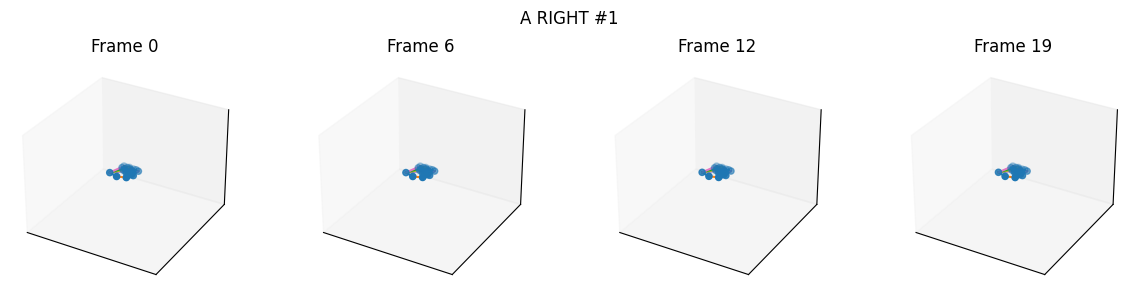

Ejemplo 1 - LEFT


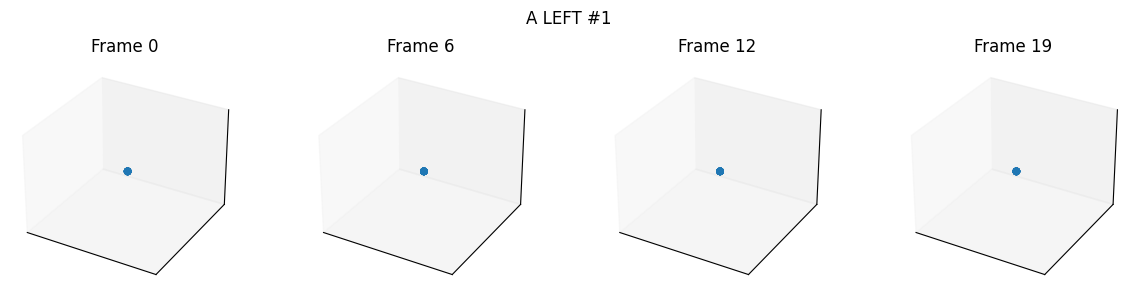

Ejemplo 2 - RIGHT


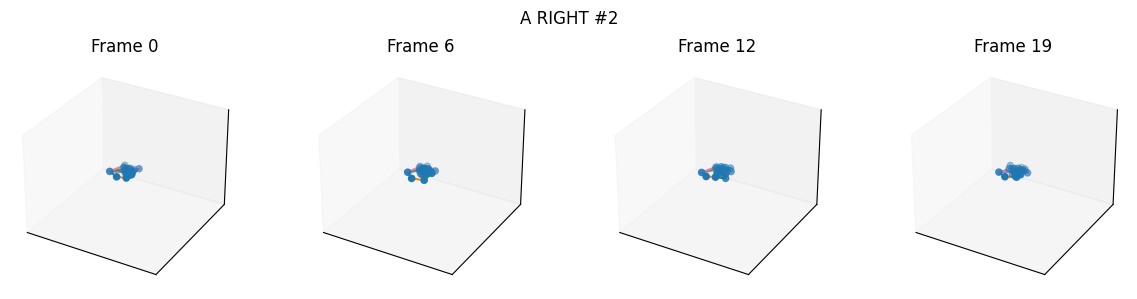

Ejemplo 2 - LEFT


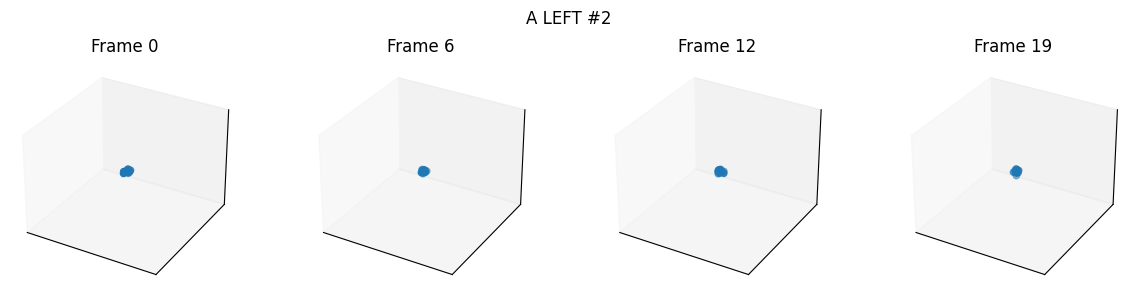

Ejemplo 3 - RIGHT


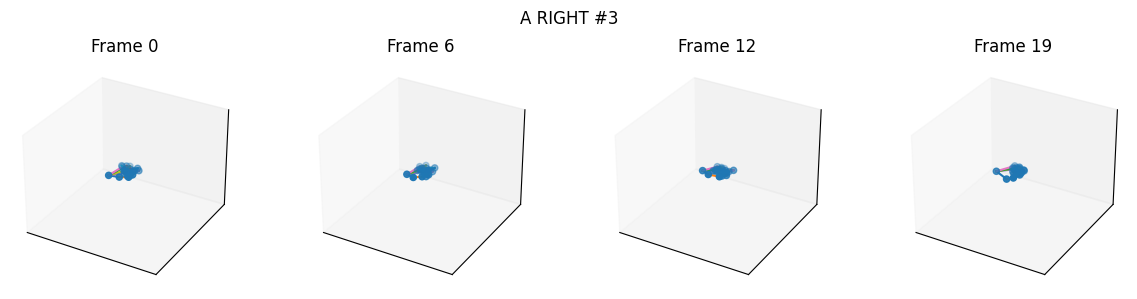

Ejemplo 3 - LEFT


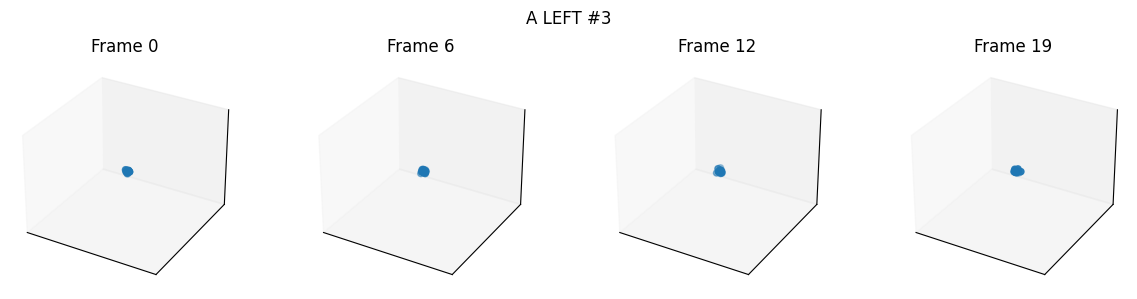


===== B =====
Ejemplo 1 - RIGHT


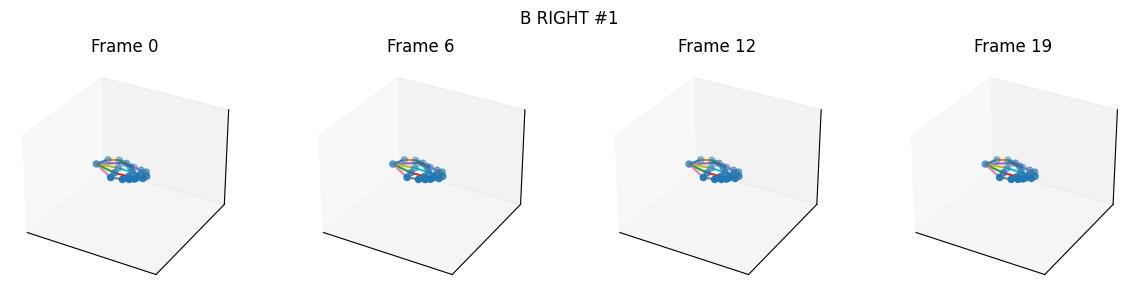

Ejemplo 1 - LEFT


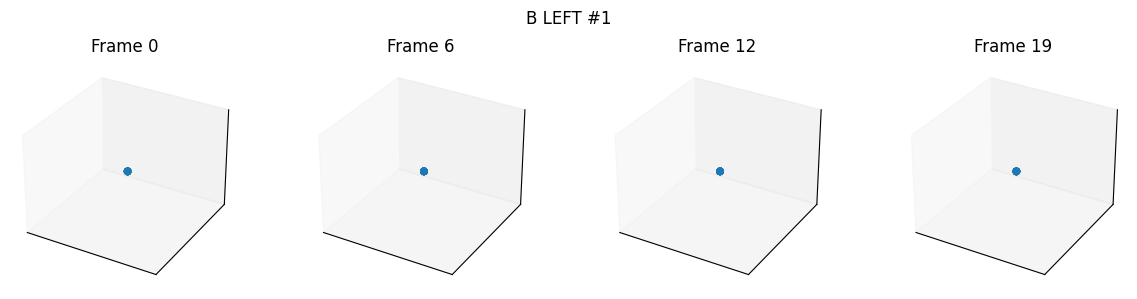

Ejemplo 2 - RIGHT


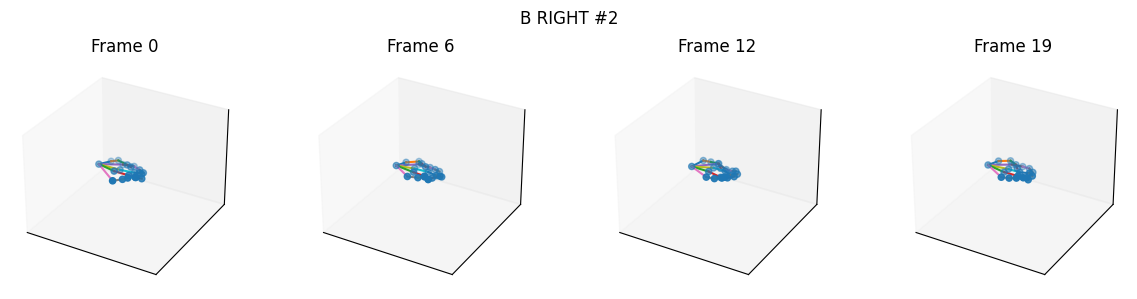

Ejemplo 2 - LEFT


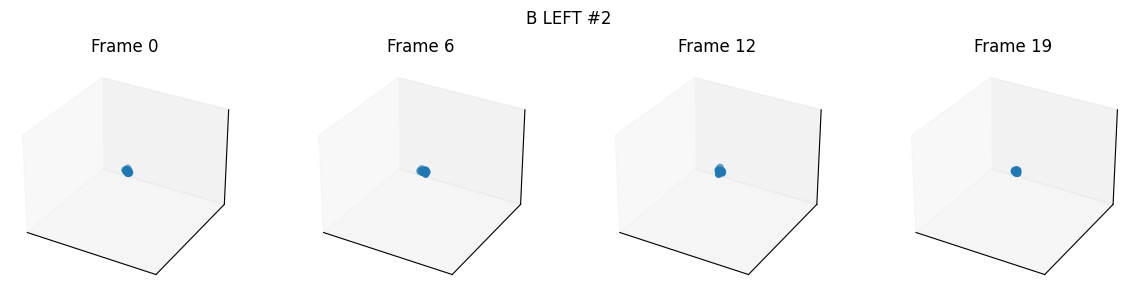

Ejemplo 3 - RIGHT


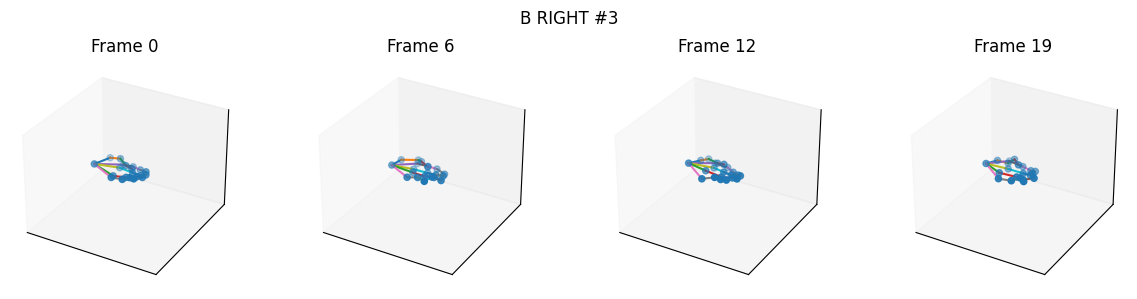

Ejemplo 3 - LEFT


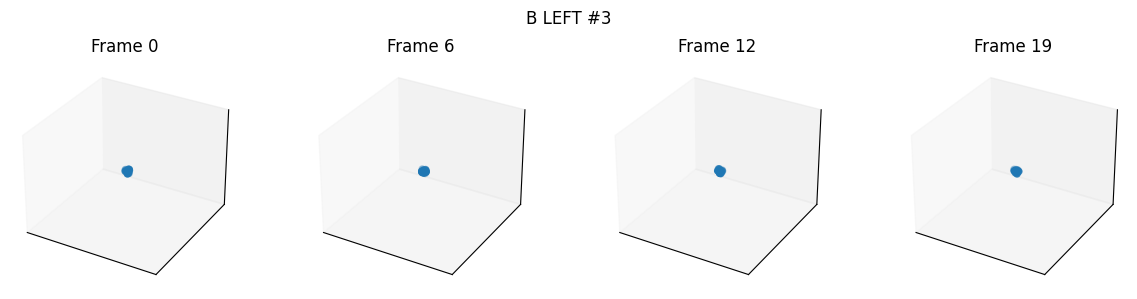


===== C =====
Ejemplo 1 - RIGHT


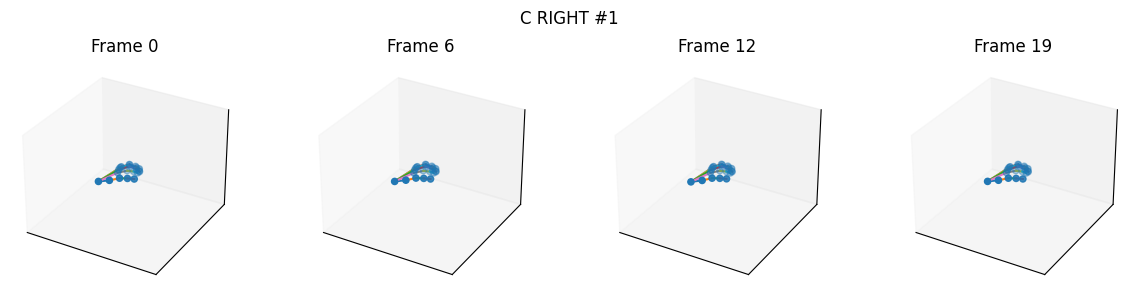

Ejemplo 1 - LEFT


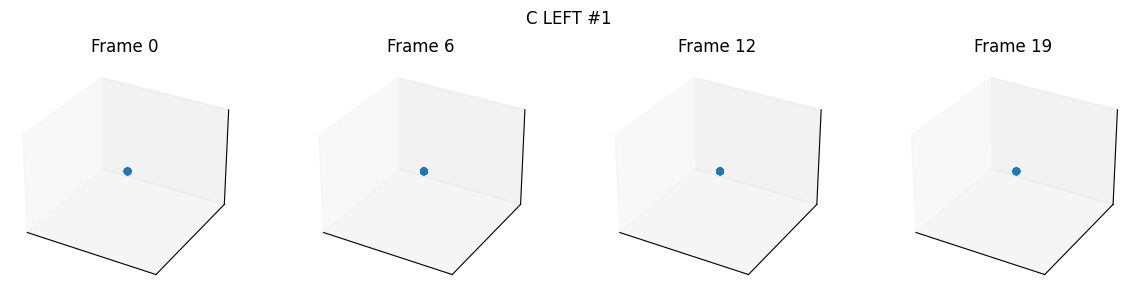

Ejemplo 2 - RIGHT


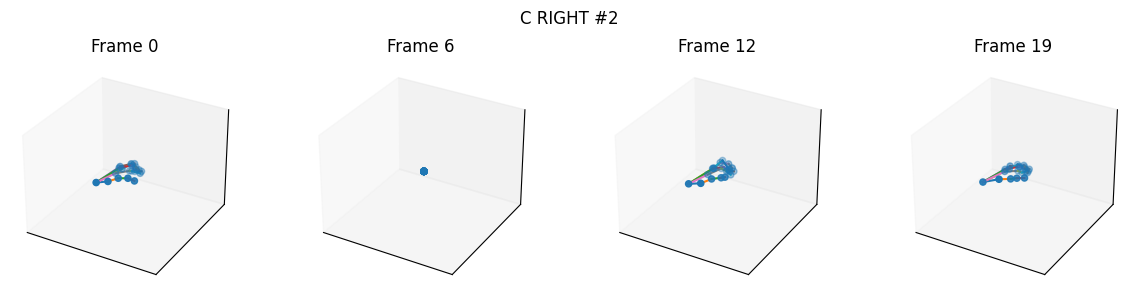

Ejemplo 2 - LEFT


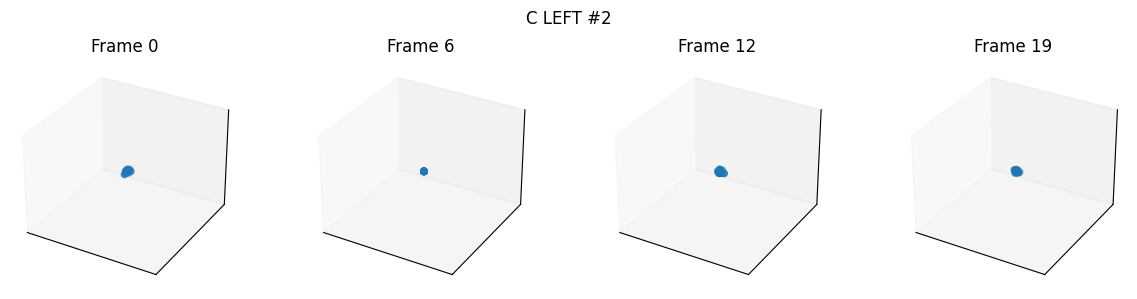

Ejemplo 3 - RIGHT


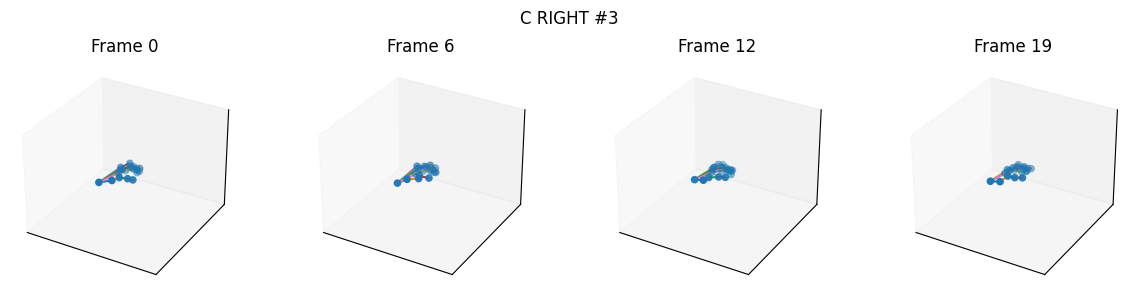

Ejemplo 3 - LEFT


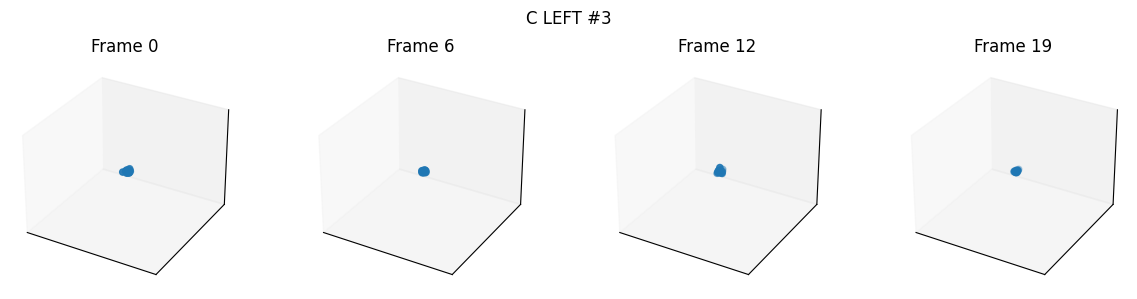


===== D =====
Ejemplo 1 - RIGHT


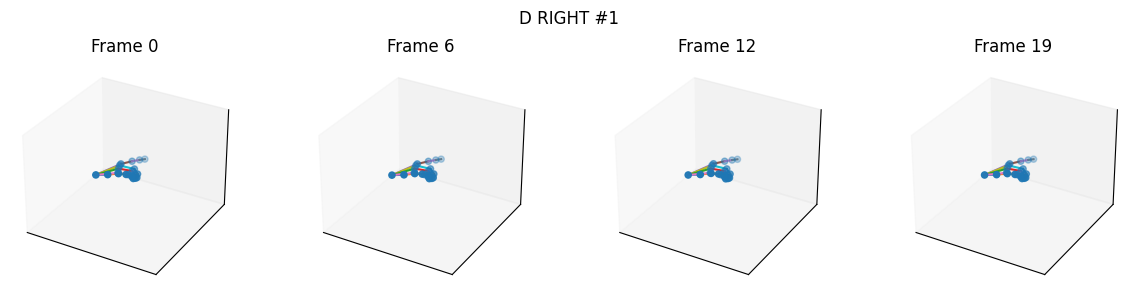

Ejemplo 1 - LEFT


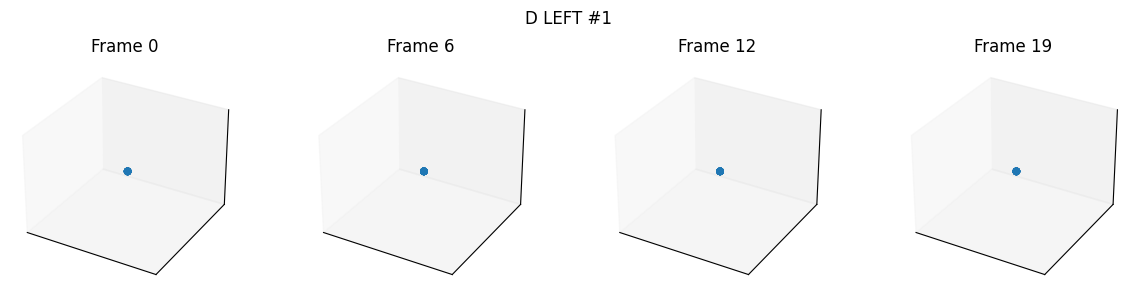

Ejemplo 2 - RIGHT


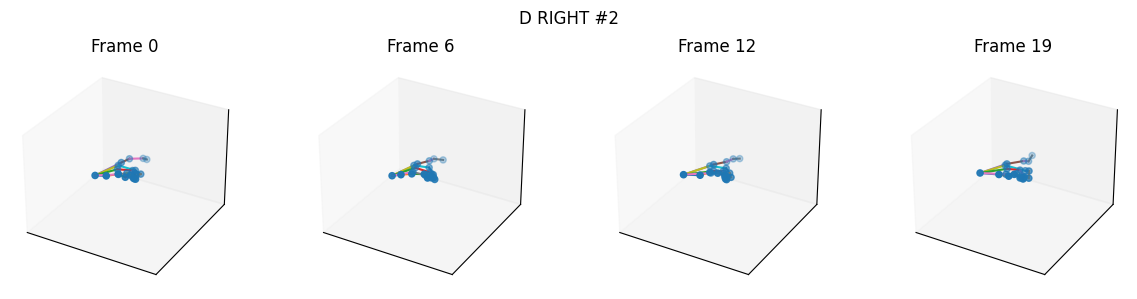

Ejemplo 2 - LEFT


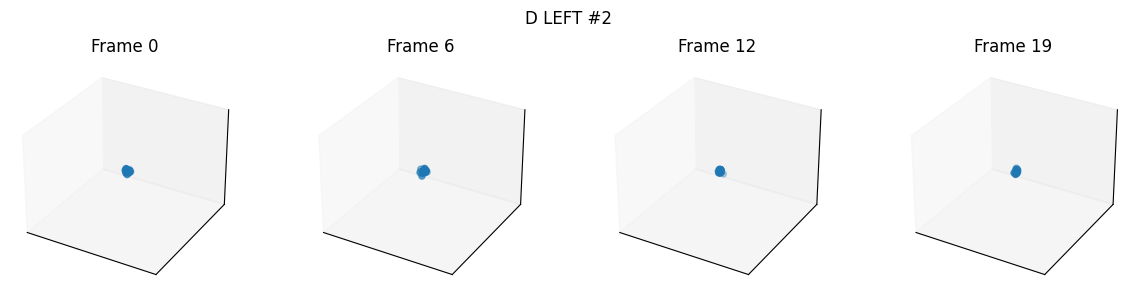

Ejemplo 3 - RIGHT


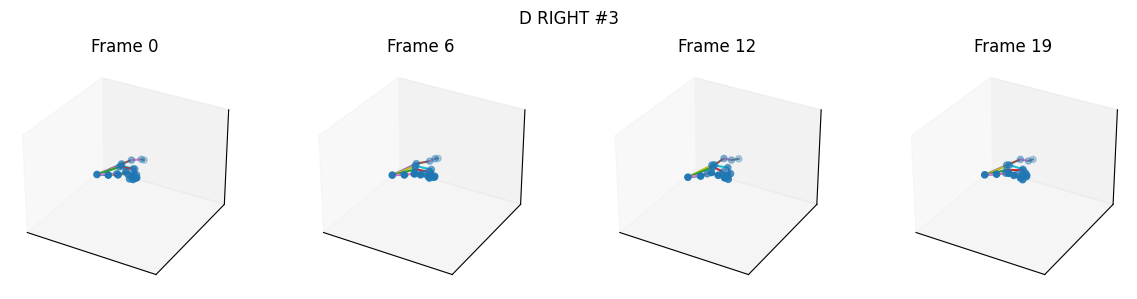

Ejemplo 3 - LEFT


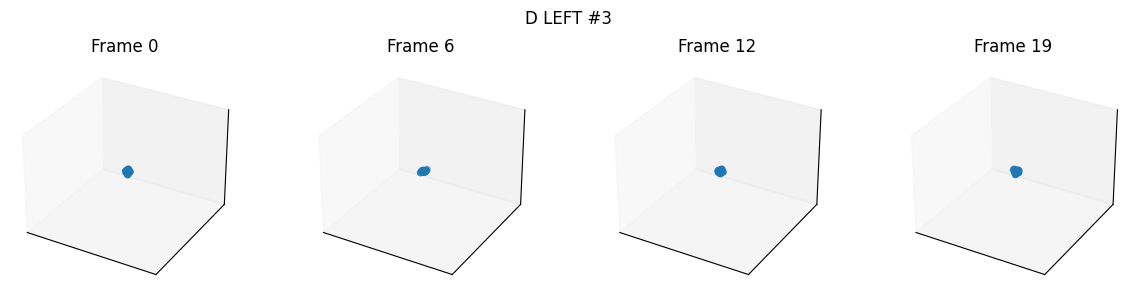


===== E =====
Ejemplo 1 - RIGHT


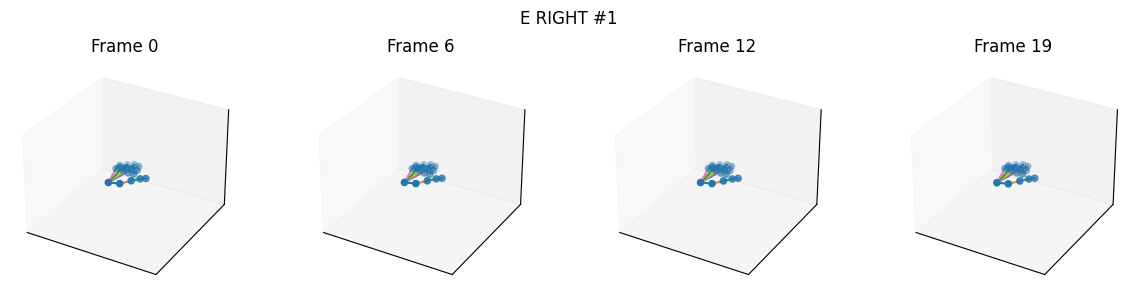

Ejemplo 1 - LEFT


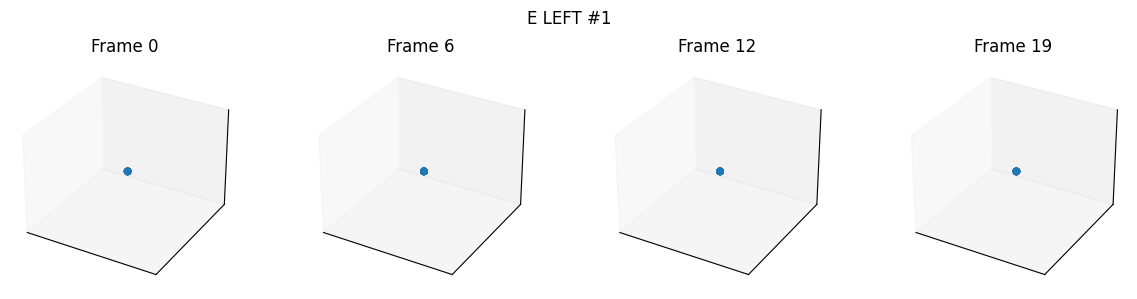

Ejemplo 2 - RIGHT


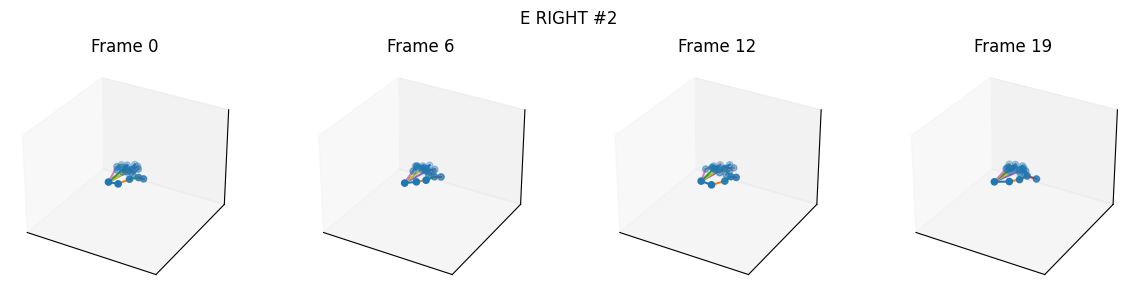

Ejemplo 2 - LEFT


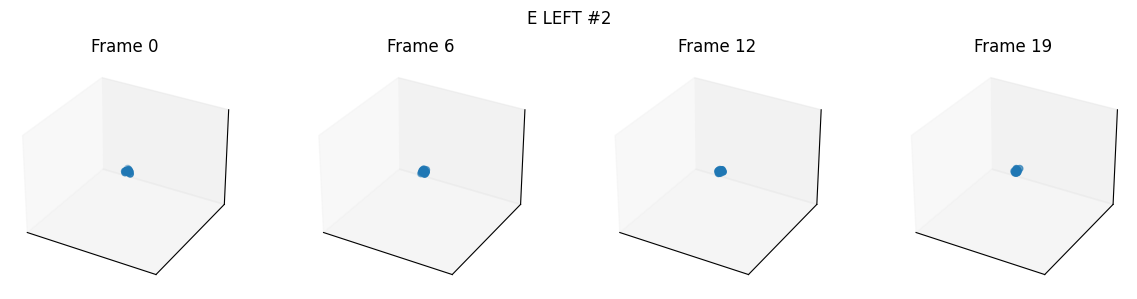

Ejemplo 3 - RIGHT


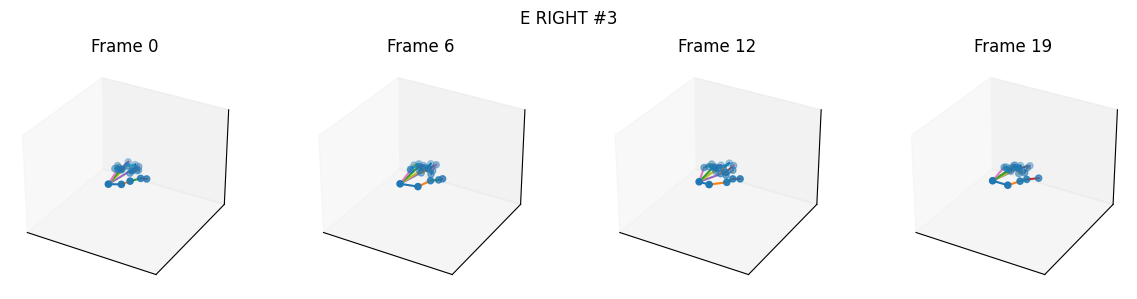

Ejemplo 3 - LEFT


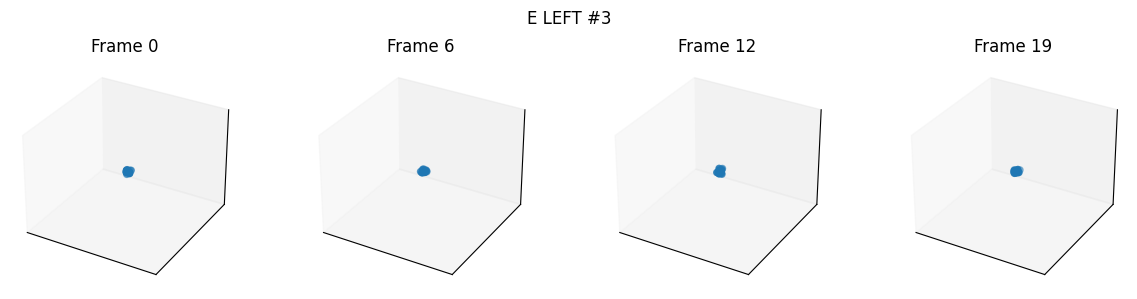


===== F =====
Ejemplo 1 - RIGHT


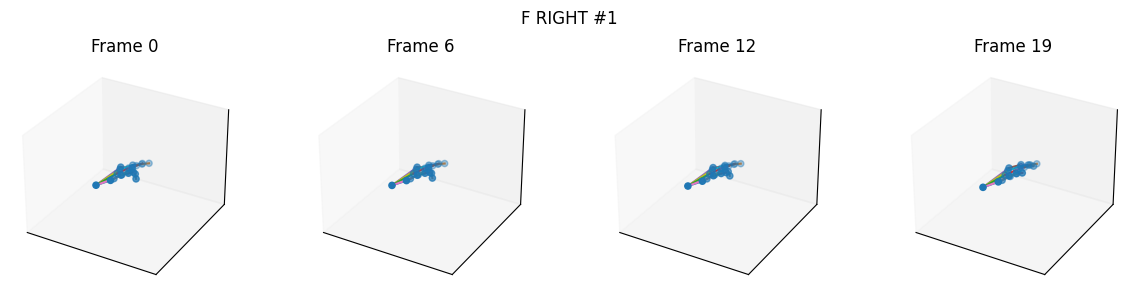

Ejemplo 1 - LEFT


KeyboardInterrupt: 

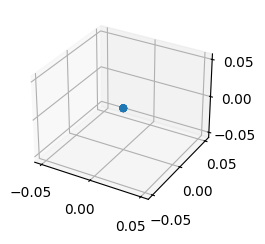

In [13]:
# ============================================================
# VISUALIZACIÓN WIREFRAME (4 FRAMES POR SECUENCIA)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import json

# ------------------------------------------------------------
# Conexiones de la mano (MediaPipe)
# ------------------------------------------------------------
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20)
]

# ------------------------------------------------------------
# Cargar configuración
# ------------------------------------------------------------
with open('../config.json', 'r') as f:
    config = json.load(f)

ACTIONS = config['common']['actions']
DATASET_PATH = config['create_dataset']['output_path']

# ------------------------------------------------------------
# Cargar dataset
# ------------------------------------------------------------
data = np.load(DATASET_PATH)
X = data["X"]   # (N, T, 42, 3)
y = data["y"]

print("Dataset cargado:")
print("X:", X.shape)
print("y:", y.shape)

# ------------------------------------------------------------
# Dibujar una mano (wireframe)
# ------------------------------------------------------------
def plot_hand(ax, points):
    """
    points: (21,3)
    """

    # puntos
    ax.scatter(points[:,0], points[:,1], points[:,2])

    # conexiones
    for (i, j) in HAND_CONNECTIONS:
        ax.plot(
            [points[i,0], points[j,0]],
            [points[i,1], points[j,1]],
            [points[i,2], points[j,2]]
        )

    # centrar visualización
    center = points.mean(axis=0)
    scale = 0.5

    ax.set_xlim(center[0]-scale, center[0]+scale)
    ax.set_ylim(center[1]-scale, center[1]+scale)
    ax.set_zlim(center[2]-scale, center[2]+scale)

    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

# ------------------------------------------------------------
# Mostrar 4 frames de una secuencia
# ------------------------------------------------------------
def visualize_sequence(seq, title=""):
    """
    seq: (T,21,3)
    """
    T = len(seq)

    # seleccionar 4 frames distribuidos
    frames_idx = np.linspace(0, T-1, 4, dtype=int)

    fig = plt.figure(figsize=(12, 3))

    for i, f_idx in enumerate(frames_idx):
        ax = fig.add_subplot(1, 4, i+1, projection='3d')
        plot_hand(ax, seq[f_idx])
        ax.set_title(f"Frame {f_idx}")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Visualizar 3 ejemplos por clase
# ------------------------------------------------------------
for label_idx, action in enumerate(ACTIONS):
    print(f"\n===== {action} =====")

    indices = np.where(y == label_idx)[0]

    if len(indices) == 0:
        print("No hay ejemplos")
        continue

    selected = indices[:3]

    for i, idx in enumerate(selected):
        seq = X[idx]  # (T,42,3)

        right_hand = seq[:, :21, :]
        left_hand  = seq[:, 21:, :]

        print(f"Ejemplo {i+1} - RIGHT")
        visualize_sequence(right_hand, f"{action} RIGHT #{i+1}")

        print(f"Ejemplo {i+1} - LEFT")
        visualize_sequence(left_hand, f"{action} LEFT #{i+1}")